<a href="https://colab.research.google.com/github/Adhira-Deogade/pytorch-learnings/blob/main/notebooks/sd/toy_example_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
!pip install smalldiffusion

In [29]:
!pip install imp

ERROR: Could not find a version that satisfies the requirement imp (from versions: none)
ERROR: No matching distribution found for imp


In [30]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from smalldiffusion import TreeDataset, training_loop, samples, ScheduleLogLinear, ConditionalMLP

def plot_batch(batch, ax=None, **kwargs):
    batch = batch.cpu().numpy()
    ax = ax or plt
    return ax.scatter(batch[:,0], batch[:,1], marker='.', **kwargs)

def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

# Removed %load_ext autoreload and %autoreload 2 as the imp module is no longer available in Python 3.12

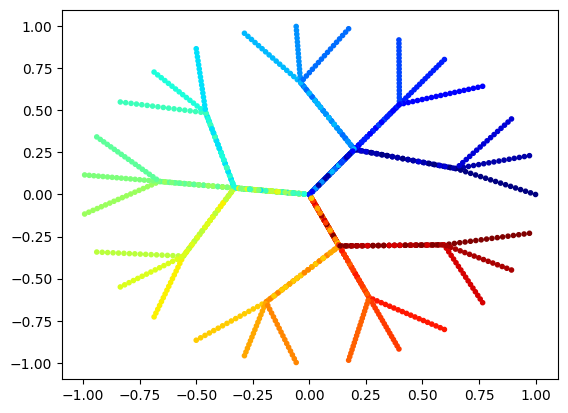

In [31]:
dataset = TreeDataset(branching_factor=3, depth=3, num_samples_per_path=50)
loader = DataLoader(dataset, batch_size=len(dataset)*2, shuffle=True)
x, labels = next(iter(loader))
plot_batch(x, c=labels, cmap='jet')
plt.show()

In [32]:
model = ConditionalMLP(dim=2, hidden_dims=(16, 128, 256, 128, 16), cond_dim=4, num_classes=dataset.total_leaves)
schedule = ScheduleLogLinear(N=200, sigma_min=0.01, sigma_max=10)
trainer = training_loop(loader, model, schedule, epochs=30000, lr=1e-3, conditional=True)
losses = [ns.loss.item() for ns in trainer]

100%|██████████| 30000/30000 [08:45<00:00, 57.04it/s]


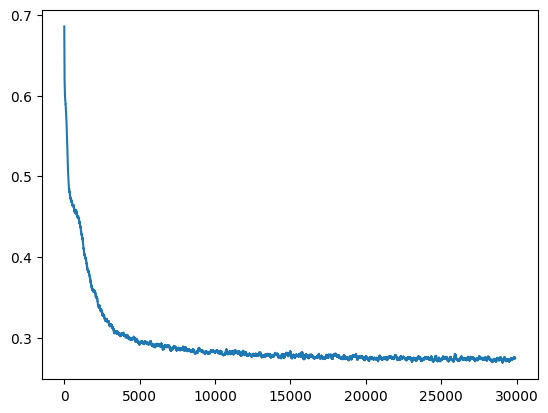

In [33]:
plt.plot(moving_average(losses, 100))
plt.show()